### Block 1: Import necessary libraries

In [15]:
from qiskit import QuantumCircuit, transpile, assemble
from qiskit.visualization import plot_histogram, circuit_drawer
from qiskit_aer import Aer
import numpy as np

### Block 2: Define the QET circuit function

In [20]:
def qet_circuit(h, k):
    """
    Constructs the quantum circuit for the QET experiment.

    Args:
      h: Parameter h for the Hamiltonian.
      k: Parameter k for the Hamiltonian.

    Returns:
      qc: The constructed QuantumCircuit object.
    """

    qc = QuantumCircuit(2, 1)

    # Prepare the ground state
    theta = -np.arccos(
        (1 / np.sqrt(2)) * np.sqrt(1 - h / np.sqrt(h**2 + k**2))
    )
    qc.ry(2 * theta, 0)
    qc.cx(0, 1)

    # Alice's measurement
    qc.h(0)  # Hadamard for X measurement

    # Bob's conditional operation
    phi = np.arcsin(
        (h * k) / np.sqrt((h**2 + 2 * k**2)**2 + h**2 * k**2)
    ) / 2

    # Alice's measurement
    qc.measure(0, 0)  # Measure qbit 0 and store the result in classical bit 0

    # Bob's conditional operation
    qc.cry(2 * phi, 0, 1).c_if(0, 0)  # Apply U(+1) if classical bit 0 is 0
    qc.cry(-2 * phi, 0, 1).c_if(0, 1)  # Apply U(-1) if classical bit 0 is 1

    # qc.cry(2 * phi, 0, 1)  # Controlled-Ry for U(+1)
    # qc.x(0)
    # qc.cry(-2 * phi, 0, 1)  # Controlled-Ry for U(-1)
    # qc.x(0)

    # Measurement preparation for V
    qc.h(1)

    # Measurement (deferred to the end)
    qc.measure_all()

    return qc

### Block 3: Simulation

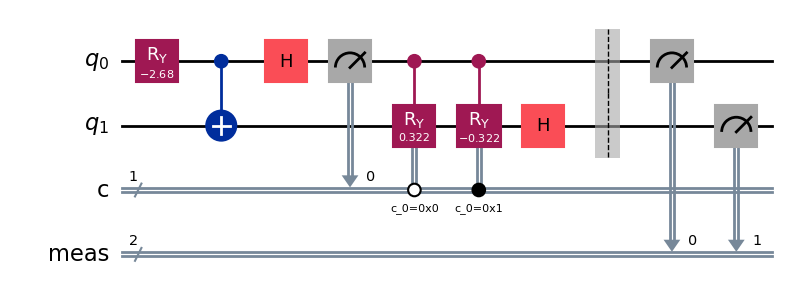

In [26]:
# Choose parameters
h = 1
k = 0.5

# Construct the circuit
qc = qet_circuit(h, k)


# Use the Qiskit simulator
simulator = Aer.get_backend('qasm_simulator')
qc_compiled = transpile(qc, simulator)

job_sim = simulator.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts_sim = result_sim.get_counts(qc_compiled)
circuit_drawer(qc, output='mpl')

### Block 3.1: Plot simulation results

Simulation results:
{'00 0': 142, '10 0': 344, '11 1': 133, '01 1': 405}


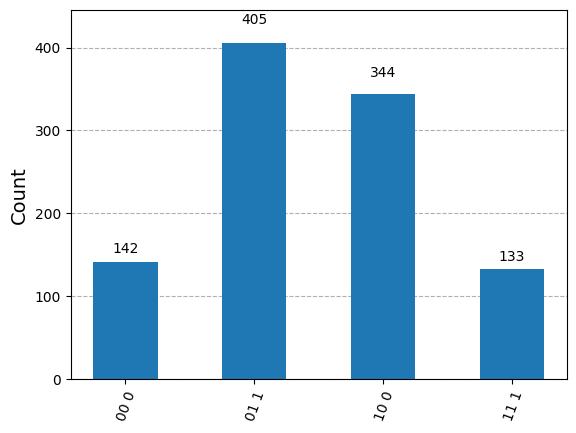

In [27]:
# Print and plot results
print("Simulation results:")
print(counts_sim)
plot_histogram(counts_sim)

### Block 4: Execution on real quantum hardware

In [29]:
# Choose IBM Quantum backend
from qiskit_ibmq_provider import IBMQ
IBMQ.load_account()
provider = IBMQ.get_provider(hub='ibm-q')
backend = provider.get_backend('ibmq_lima')  # Choose your preferred backend

# Construct the circuit (same as before)
qc = qet_circuit(h, k)

# Transpile and assemble for the backend
qc_compiled = transpile(qc, backend)
job_real = assemble(qc_compiled, shots=1024)

# Execute on the backend
result_real = backend.run(job_real).result()
counts_real = result_real.get_counts(qc_compiled)

# Print and plot results
print("Real quantum computer results:")
print(counts_real)
plot_histogram(counts_real)

ModuleNotFoundError: No module named 'qiskit_ibmq_provider'

### Block 5: Analyze the results

In [ ]:
# ... (Refer to the paper for analysis techniques)